# Машины опорных векторов (SVM)

Машина опорных векторов (SVM) — алгоритм, ищущий оптимальную разделяющую гиперплоскость, которая максимизирует отступ (margin) между классами.

# Используемые библиотеки

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import recall_score, f1_score, precision_score

# Описание и демонстрация датасета

Датасет представляет из себя данные пациентов. Цель модели - предсказывать пациентов, у которых диабет

In [ ]:
path_to_dataset = kagglehub.dataset_download("hassinarman/diabetes-bangladesh")
df = pd.read_csv(path_to_dataset + '/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv')

df['diabetic'] = df['diabetic'].map({'Yes': 1, 'No': 0})
y = df['diabetic']
X = df.drop(columns=['diabetic'])

print(f"Размер датасета: {df.shape}")
display(X.head())
X.info()

Using Colab cache for faster access to the 'diabetes-bangladesh' dataset.
Размер датасета: (5288, 15)


,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   object 
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
dtypes: float64(4), int64(9), object(1)
memor

# Препроцессинг датасета

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

NUM_COLUMNS = X_train.select_dtypes(include=np.number).columns.tolist()
CAT_COLUMNS = X_train.select_dtypes(include='object').columns.tolist()

# SVM также требует строгой масштабизации
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_COLUMNS),
        ('num', StandardScaler(), NUM_COLUMNS)
    ]
)

pipeline = Pipeline([
    ('preprocess', preprocessor)
])

X_train_scaled = pd.DataFrame(pipeline.fit_transform(X_train))
X_test_scaled = pd.DataFrame(pipeline.transform(X_test))
X_train_scaled.columns = pipeline.named_steps['preprocess'].get_feature_names_out()
X_test_scaled.columns = pipeline.named_steps['preprocess'].get_feature_names_out()

# Тепловая карта

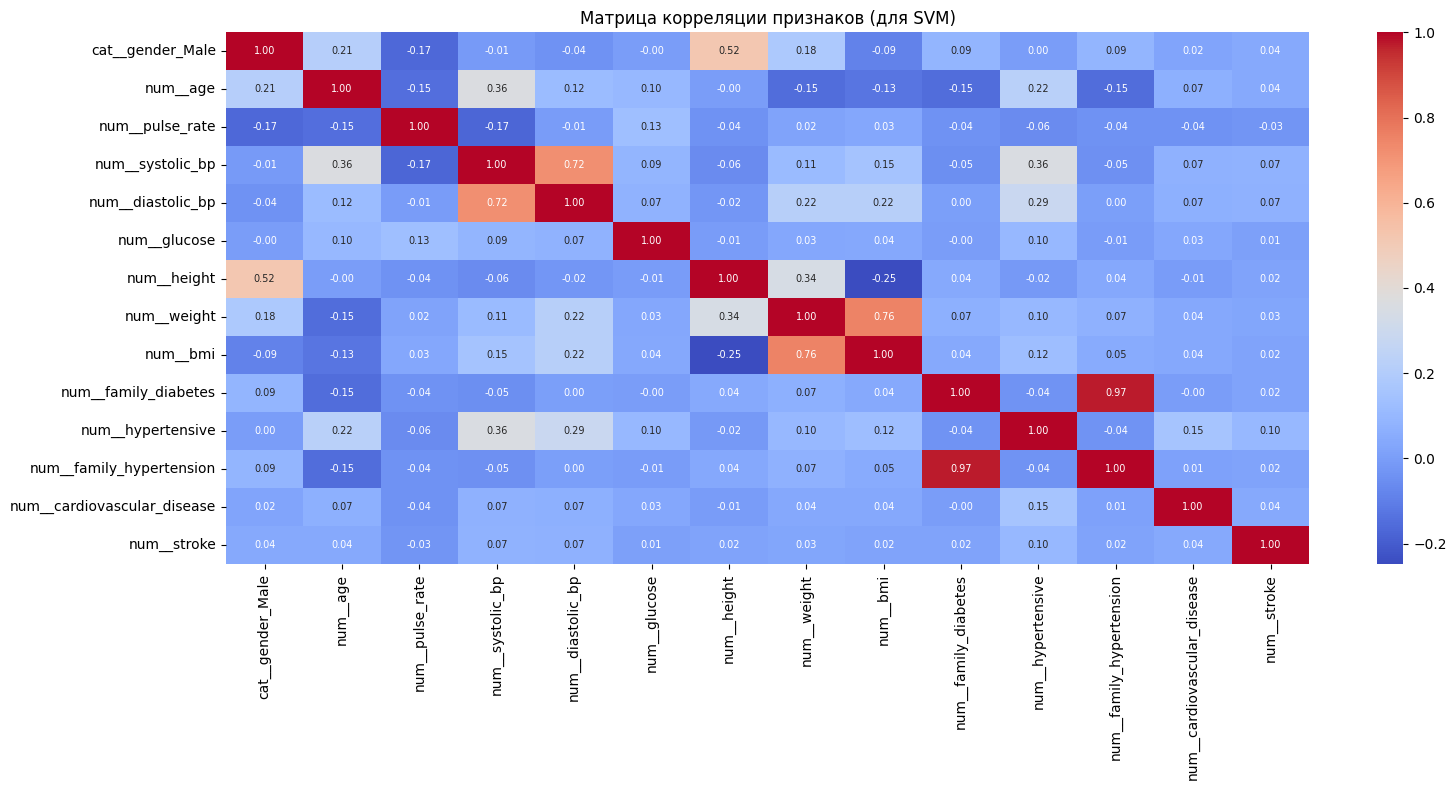

In [ ]:
plt.figure(figsize=(16, 8))
sns.heatmap(X_train_scaled.corr(), annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 7})
plt.title("Матрица корреляции признаков (для SVM)")
plt.tight_layout()
plt.show()

# Обучение модели

In [ ]:
svm_model = SVC(
    kernel='linear',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

print("SVM модель успешно обучена.")
print(f"Точность на обучающей выборке: {svm_model.score(X_train_scaled, y_train):.4f}")

SVM модель успешно обучена.
Точность на обучающей выборке: 0.8641


# Тестирование модели

In [ ]:
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]


print(" Отчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=['Здоров (0)', 'Диабет (1)']))

 Отчёт по классификации:
              precision    recall  f1-score   support

  Здоров (0)       0.97      0.87      0.92      1469
  Диабет (1)       0.30      0.69      0.42       118

    accuracy                           0.86      1587
   macro avg       0.64      0.78      0.67      1587
weighted avg       0.92      0.86      0.88      1587



# Визуализация результатов

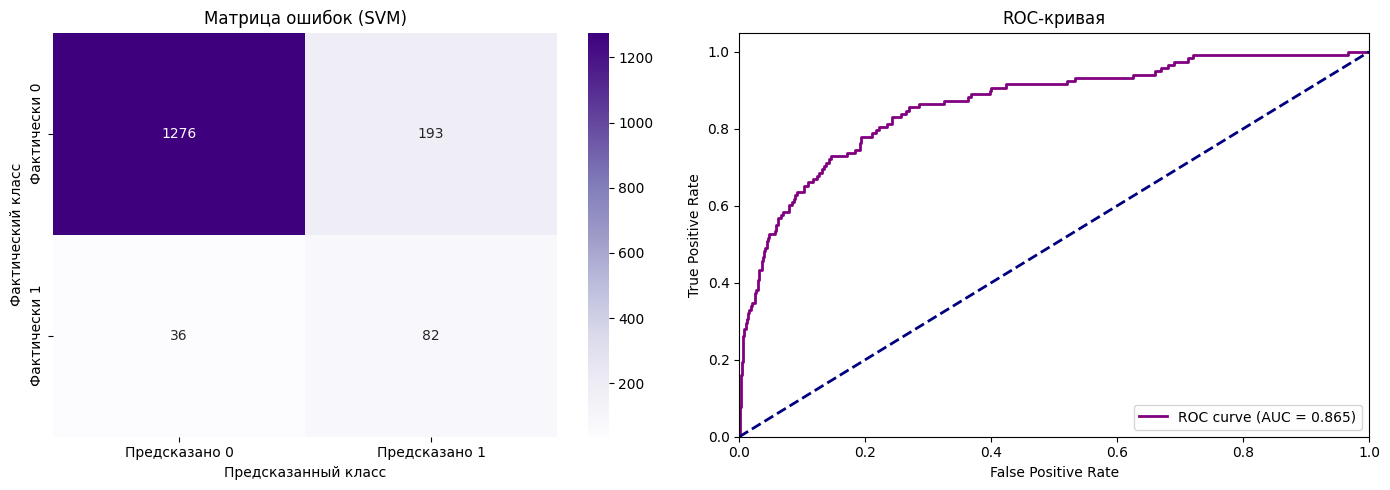

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Предсказано 0', 'Предсказано 1'],
            yticklabels=['Фактически 0', 'Фактически 1'])
axes[0].set_title('Матрица ошибок (SVM)')
axes[0].set_ylabel('Фактический класс')
axes[0].set_xlabel('Предсказанный класс')

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()